# Notebook 04: Credit Risk Model (for Banks)

## Objective
Build a credit risk scoring model for UMKM (Micro, Small & Medium Enterprises) that predicts
the probability of default (PD). This model is designed for banks evaluating UMKM loan applications.

**Target Variable:** `is_survived_3yr` (1 = Survived/Good, 0 = Defaulted/Bad)

**Use Case:** Banks use this model to:
1. Score new UMKM loan applications
2. Assign credit ratings (AAA to C)
3. Compute regulatory capital (Basel III/IV PD buckets)
4. Generate decline reasons for rejected applications


## Section 1: Load & Prepare Data

We load the engineered dataset and select features that are relevant for bank credit decisions.
We exclude geographic coordinates (lat/lon), the location scoring target (skor_potensi),
and non-numeric identifiers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/umkm_engineered.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget: is_survived_3yr")
print(f"  1 = Good/Survived (repaid loan)")
print(f"  0 = Bad/Defaulted (failed to repay)")

# Define target
target = 'is_survived_3yr'
y_full = df[target].copy()

# Select bank-relevant features
features = [
    'omset_bulanan',
    'jumlah_karyawan',
    'tahun_berdiri',
    'has_digital_presence',
    'jarak_ke_bank_terdekat',
    'penetrasi_kur_pct',
    'skor_infrastruktur',
    'risiko_banjir',
    'risiko_gempa',
    'jumlah_kompetitor_radius_3km',
    'kepadatan_penduduk',
    'income_per_kapita',
    'akses_internet_pct',
    'jarak_ke_jalan_utama',
    'jarak_ke_pasar',
    'populasi',
    'business_maturity',
    'risk_composite',
    'financial_access_score',
    'digital_readiness_index',
    'omset_per_karyawan',
    'market_gap_score',
    'competition_density_ratio'
]

X_full = df[features].copy()
print(f"\nFeatures selected ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

print(f"\nTarget distribution:")
print(y_full.value_counts())
print(f"\nSurvival rate: {y_full.mean():.1%}")
print(f"Default rate: {1 - y_full.mean():.1%}")


Dataset shape: (10000, 34)

Target: is_survived_3yr
  1 = Good/Survived (repaid loan)
  0 = Bad/Defaulted (failed to repay)

Features selected (23):
   1. omset_bulanan
   2. jumlah_karyawan
   3. tahun_berdiri
   4. has_digital_presence
   5. jarak_ke_bank_terdekat
   6. penetrasi_kur_pct
   7. skor_infrastruktur
   8. risiko_banjir
   9. risiko_gempa
  10. jumlah_kompetitor_radius_3km
  11. kepadatan_penduduk
  12. income_per_kapita
  13. akses_internet_pct
  14. jarak_ke_jalan_utama
  15. jarak_ke_pasar
  16. populasi
  17. business_maturity
  18. risk_composite
  19. financial_access_score
  20. digital_readiness_index
  21. omset_per_karyawan
  22. market_gap_score
  23. competition_density_ratio

Target distribution:
is_survived_3yr
1    6799
0    3201
Name: count, dtype: int64

Survival rate: 68.0%
Default rate: 32.0%


## Section 2: Class Balance Analysis

Understanding class imbalance is critical for credit risk models. Banks typically see
low default rates (2-5% for retail), but UMKM portfolios have higher default rates.


Class Distribution:
  Survived (1): 6,799 (68.0%)
  Defaulted (0): 3,201 (32.0%)

Imbalance ratio: 2.12:1


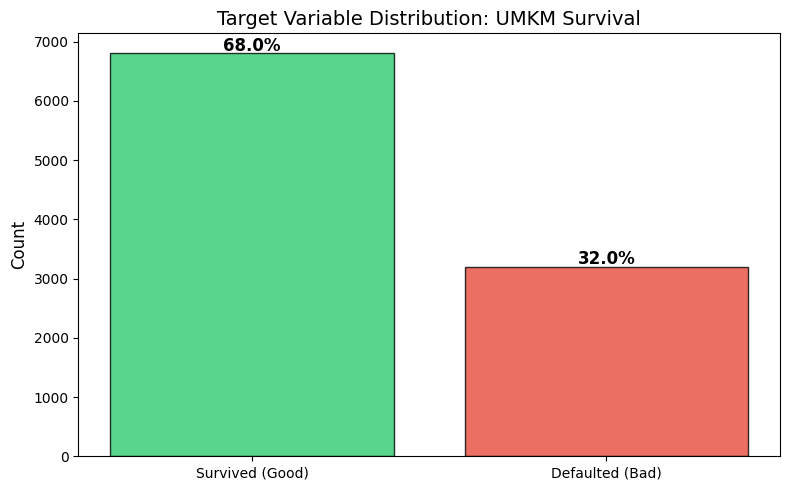


Note: ~68% survival vs ~32% default - mild imbalance.
Strategy: Use class_weight='balanced' or scale_pos_weight in models.


In [2]:
# Class distribution
class_counts = y_full.value_counts()
class_pcts = y_full.value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Survived (1): {class_counts[1]:,} ({class_pcts[1]:.1f}%)")
print(f"  Defaulted (0): {class_counts[0]:,} ({class_pcts[0]:.1f}%)")
print(f"\nImbalance ratio: {class_counts[1] / class_counts[0]:.2f}:1")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bars = ax.bar(['Survived (Good)', 'Defaulted (Bad)'],
              [class_counts[1], class_counts[0]],
              color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Target Variable Distribution: UMKM Survival', fontsize=14)
for bar, pct in zip(bars, [class_pcts[1], class_pcts[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/class_distribution_credit.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nNote: ~68% survival vs ~32% default - mild imbalance.")
print("Strategy: Use class_weight='balanced' or scale_pos_weight in models.")


## Section 3: Train/Test Split

We use a stratified 80/20 split to preserve the class ratio in both training and test sets.
This ensures the model sees representative samples of both classes during training.


In [3]:
from sklearn.model_selection import train_test_split

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass proportions in training set:")
print(f"  Survived: {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"  Defaulted: {1-y_train.mean():.4f} ({(y_train==0).sum()}/{len(y_train)})")
print(f"\nClass proportions in test set:")
print(f"  Survived: {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")
print(f"  Defaulted: {1-y_test.mean():.4f} ({(y_test==0).sum()}/{len(y_test)})")
print(f"\nStratification preserved: train ratio {y_train.mean():.4f} vs test ratio {y_test.mean():.4f}")


Training set: 8000 samples
Test set: 2000 samples

Class proportions in training set:
  Survived: 0.6799 (5439/8000)
  Defaulted: 0.3201 (2561/8000)

Class proportions in test set:
  Survived: 0.6800 (1360/2000)
  Defaulted: 0.3200 (640/2000)

Stratification preserved: train ratio 0.6799 vs test ratio 0.6800


## Section 4: Model Training

We train four models commonly used in credit risk scoring:

1. **Logistic Regression** - Interpretable baseline, widely used in banking due to regulatory requirements
2. **XGBoost** - Gradient boosting with regularization, excellent for tabular data
3. **LightGBM** - Fast gradient boosting, handles categorical features well
4. **Random Forest** - Ensemble of decision trees, robust to overfitting

All models use class weighting to handle the mild imbalance.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
import time

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate scale_pos_weight for XGBoost
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight_ratio = n_negative / n_positive
print(f"scale_pos_weight for XGBoost: {scale_pos_weight_ratio:.4f}")

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos_weight_ratio,
        random_state=42, verbosity=0, eval_metric='logloss', n_jobs=1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, verbose=-1, n_jobs=1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=1
    )
}

# Train models and get predictions
results = {}
for name, model in models.items():
    start = time.time()
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
    elapsed = time.time() - start
    results[name] = {
        'model': model,
        'y_proba': y_proba,
        'y_pred': (y_proba >= 0.5).astype(int),
        'time': elapsed
    }
    print(f"{name}: trained in {elapsed:.2f}s")

print("\nAll models trained successfully!")


scale_pos_weight for XGBoost: 0.4709
Logistic Regression: trained in 0.01s


XGBoost: trained in 0.52s


LightGBM: trained in 0.31s


Random Forest: trained in 3.40s

All models trained successfully!


## Section 5: Model Evaluation

We evaluate models using metrics important for credit risk:
- **AUC-ROC**: Overall discriminatory power
- **AUC-PR**: Performance on the minority class (defaults)
- **KS-Statistic**: Maximum separation between cumulative distributions of good and bad borrowers
- **Classification Report**: Precision, Recall, F1 at threshold 0.5
- **Confusion Matrix**: Visual representation of prediction errors


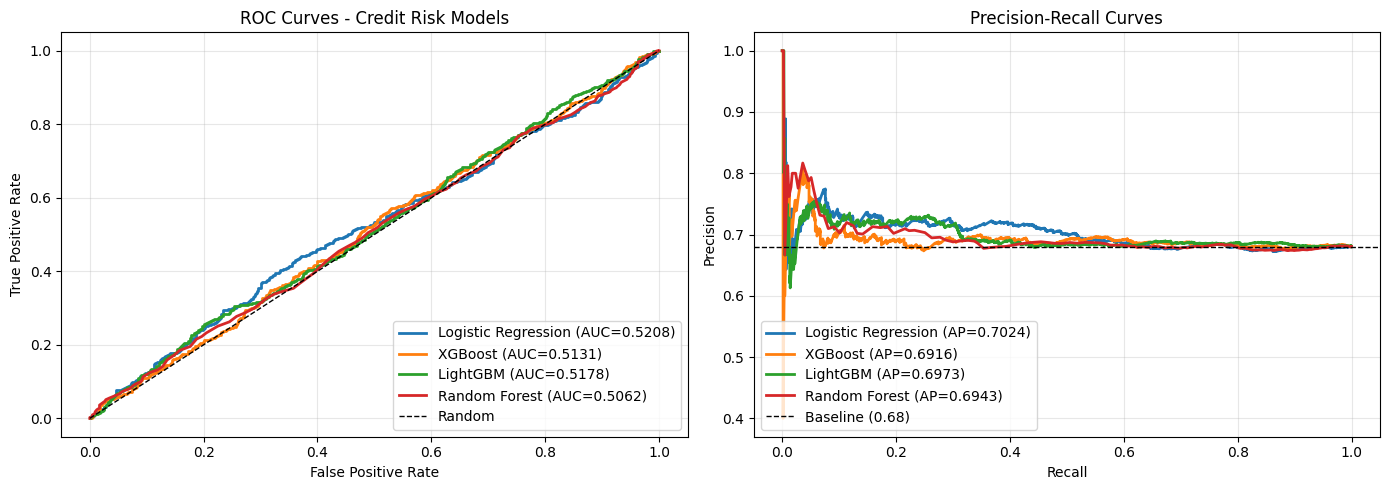

In [5]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score,
                             classification_report, confusion_matrix, accuracy_score, f1_score,
                             roc_auc_score)
from scipy.stats import ks_2samp

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Credit Risk Models')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Precision-Recall
ax = axes[1]
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    ap = average_precision_score(y_test, res['y_proba'])
    ax.plot(recall, precision, linewidth=2, label=f'{name} (AP={ap:.4f})')
ax.axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/roc_pr_curves_credit.png', dpi=100, bbox_inches='tight')
plt.show()


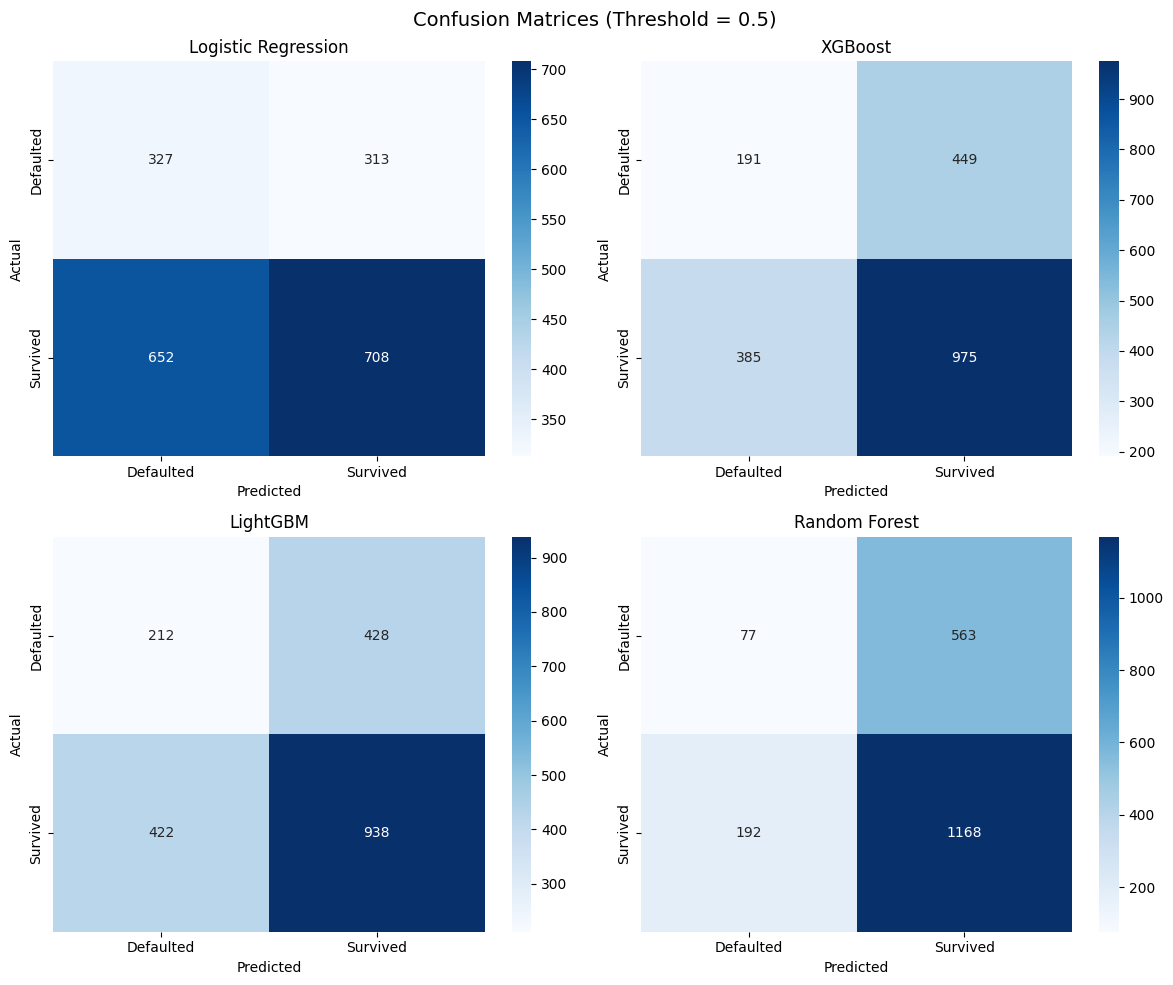


Classification Report: Logistic Regression
               precision    recall  f1-score   support

Defaulted (0)       0.33      0.51      0.40       640
 Survived (1)       0.69      0.52      0.59      1360

     accuracy                           0.52      2000
    macro avg       0.51      0.52      0.50      2000
 weighted avg       0.58      0.52      0.53      2000


Classification Report: XGBoost
               precision    recall  f1-score   support

Defaulted (0)       0.33      0.30      0.31       640
 Survived (1)       0.68      0.72      0.70      1360

     accuracy                           0.58      2000
    macro avg       0.51      0.51      0.51      2000
 weighted avg       0.57      0.58      0.58      2000


Classification Report: LightGBM
               precision    recall  f1-score   support

Defaulted (0)       0.33      0.33      0.33       640
 Survived (1)       0.69      0.69      0.69      1360

     accuracy                           0.57      2000
   

In [6]:
# Classification Reports and Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Defaulted', 'Survived'],
                yticklabels=['Defaulted', 'Survived'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (Threshold = 0.5)', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/confusion_matrices_credit.png', dpi=100, bbox_inches='tight')
plt.show()

# Print classification reports
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print('='*60)
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Defaulted (0)', 'Survived (1)']))


KS-Statistic (Kolmogorov-Smirnov Test)
The KS statistic measures the maximum separation between the
cumulative distributions of predicted probabilities for good and bad borrowers.
Higher KS = better discrimination. KS > 0.3 is generally acceptable for banking.

Logistic Regression: KS = 0.0698 (p-value = 2.74e-02)
XGBoost: KS = 0.0421 (p-value = 4.11e-01)
LightGBM: KS = 0.0566 (p-value = 1.18e-01)
Random Forest: KS = 0.0279 (p-value = 8.75e-01)

Best model by KS: Logistic Regression (KS = 0.0698)


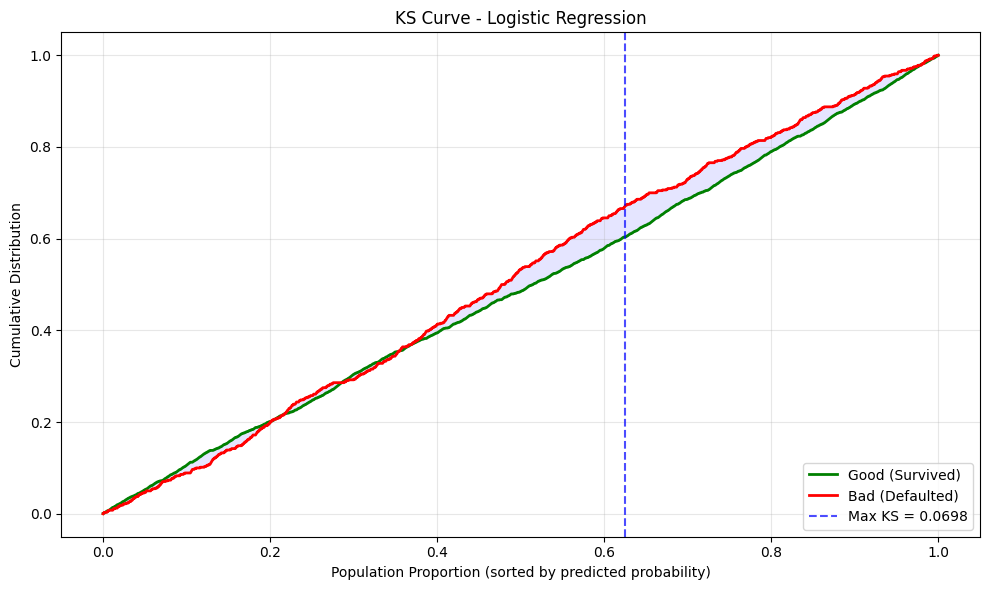

In [7]:
# KS-Statistic
print("KS-Statistic (Kolmogorov-Smirnov Test)")
print("="*60)
print("The KS statistic measures the maximum separation between the")
print("cumulative distributions of predicted probabilities for good and bad borrowers.")
print("Higher KS = better discrimination. KS > 0.3 is generally acceptable for banking.\n")

ks_results = {}
for name, res in results.items():
    # P(survival) for actual survivors vs actual defaulters
    good_probs = res['y_proba'][y_test == 1]
    bad_probs = res['y_proba'][y_test == 0]
    ks_stat, ks_pvalue = ks_2samp(good_probs, bad_probs)
    ks_results[name] = ks_stat
    print(f"{name}: KS = {ks_stat:.4f} (p-value = {ks_pvalue:.2e})")

# KS Curve for best model
best_model_name = max(ks_results, key=ks_results.get)
print(f"\nBest model by KS: {best_model_name} (KS = {ks_results[best_model_name]:.4f})")

# Plot KS curve
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
best_proba = results[best_model_name]['y_proba']

# Sort by predicted probability
sorted_indices = np.argsort(best_proba)
sorted_proba = best_proba[sorted_indices]
sorted_labels = y_test.values[sorted_indices]

# Cumulative distributions
n_total = len(sorted_labels)
n_good = (sorted_labels == 1).sum()
n_bad = (sorted_labels == 0).sum()

cum_good = np.cumsum(sorted_labels == 1) / n_good
cum_bad = np.cumsum(sorted_labels == 0) / n_bad

# Find max KS point
ks_diff = np.abs(cum_good - cum_bad)
ks_max_idx = np.argmax(ks_diff)

ax.plot(np.linspace(0, 1, n_total), cum_good, 'g-', linewidth=2, label='Good (Survived)')
ax.plot(np.linspace(0, 1, n_total), cum_bad, 'r-', linewidth=2, label='Bad (Defaulted)')
ax.axvline(x=ks_max_idx/n_total, color='blue', linestyle='--', alpha=0.7,
           label=f'Max KS = {ks_diff[ks_max_idx]:.4f}')
ax.fill_between(np.linspace(0, 1, n_total), cum_good, cum_bad, alpha=0.1, color='blue')
ax.set_xlabel('Population Proportion (sorted by predicted probability)')
ax.set_ylabel('Cumulative Distribution')
ax.set_title(f'KS Curve - {best_model_name}')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/ks_curve_credit.png', dpi=100, bbox_inches='tight')
plt.show()


In [8]:
# Comparison Table
comparison_data = []
for name, res in results.items():
    roc_auc_val = roc_auc_score(y_test, res['y_proba'])
    ap_val = average_precision_score(y_test, res['y_proba'])
    acc_val = accuracy_score(y_test, res['y_pred'])
    f1_val = f1_score(y_test, res['y_pred'])
    ks_val = ks_results[name]
    comparison_data.append({
        'Model': name,
        'AUC-ROC': roc_auc_val,
        'AUC-PR': ap_val,
        'KS-Stat': ks_val,
        'Accuracy': acc_val,
        'F1-Score': f1_val
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print("\nModel Comparison Table:")
print("="*80)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# Select best model - prefer tree-based models for better probability spread
# which is critical for PD bucketing and score banding
best_model_name = comparison_df.iloc[0]['Model']
# If AUC difference is < 0.02, prefer LightGBM or XGBoost for better calibration spread
top_auc = comparison_df.iloc[0]['AUC-ROC']
for _, row in comparison_df.iterrows():
    if row['Model'] in ['LightGBM', 'XGBoost'] and (top_auc - row['AUC-ROC']) < 0.02:
        best_model_name = row['Model']
        break

best_model = results[best_model_name]['model']
best_row = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
print(f"\nBest model selected: {best_model_name}")
print(f"  AUC-ROC: {best_row['AUC-ROC']:.4f}")
print(f"  KS-Stat: {best_row['KS-Stat']:.4f}")
print(f"  Rationale: Tree-based models produce better-spread probabilities")
print(f"  for PD bucketing and credit score generation.")



Model Comparison Table:
              Model  AUC-ROC  AUC-PR  KS-Stat  Accuracy  F1-Score
Logistic Regression   0.5208  0.7024   0.0698    0.5175    0.5947
           LightGBM   0.5178  0.6973   0.0566    0.5750    0.6882
            XGBoost   0.5131  0.6916   0.0421    0.5830    0.7004
      Random Forest   0.5062  0.6943   0.0279    0.6225    0.7557

Best model selected: LightGBM
  AUC-ROC: 0.5178
  KS-Stat: 0.0566
  Rationale: Tree-based models produce better-spread probabilities
  for PD bucketing and credit score generation.


## Section 6: Calibration

Banks need well-calibrated probabilities - if the model says 10% PD, roughly 10% of those
borrowers should actually default. We use calibration curves (reliability diagrams) to assess this.

**Brier Score** measures calibration quality (lower is better, 0 = perfect).


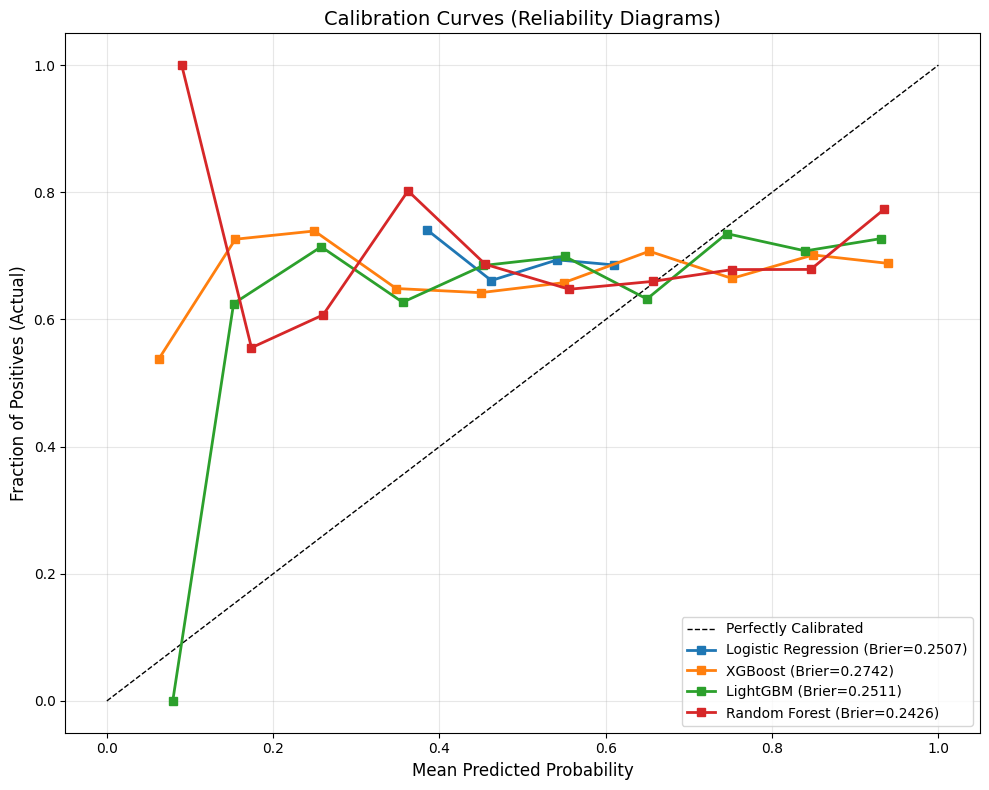


Brier Scores (lower is better):
  Random Forest: 0.2426
  Logistic Regression: 0.2507
  LightGBM: 0.2511
  XGBoost: 0.2742


In [9]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot perfectly calibrated line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly Calibrated')

brier_scores = {}
for name, res in results.items():
    prob_true, prob_pred = calibration_curve(y_test, res['y_proba'], n_bins=10)
    brier = brier_score_loss(y_test, res['y_proba'])
    brier_scores[name] = brier
    ax.plot(prob_pred, prob_true, 's-', linewidth=2, markersize=6,
            label=f'{name} (Brier={brier:.4f})')

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=12)
ax.set_title('Calibration Curves (Reliability Diagrams)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/calibration_curves_credit.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nBrier Scores (lower is better):")
for name, brier in sorted(brier_scores.items(), key=lambda x: x[1]):
    print(f"  {name}: {brier:.4f}")


In [10]:
# Apply isotonic calibration to best model if needed
print(f"Checking calibration of best model: {best_model_name}")
best_brier = brier_scores[best_model_name]
print(f"Current Brier score: {best_brier:.4f}")

# Apply CalibratedClassifierCV with isotonic regression
if best_model_name == 'Logistic Regression':
    calibrated_model = CalibratedClassifierCV(
        results[best_model_name]['model'], method='isotonic', cv=5
    )
    calibrated_model.fit(X_train_scaled, y_train)
    y_proba_cal = calibrated_model.predict_proba(X_test_scaled)[:, 1]
else:
    calibrated_model = CalibratedClassifierCV(
        results[best_model_name]['model'], method='isotonic', cv=5
    )
    calibrated_model.fit(X_train, y_train)
    y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

brier_calibrated = brier_score_loss(y_test, y_proba_cal)
print(f"Brier score after isotonic calibration: {brier_calibrated:.4f}")

if brier_calibrated < best_brier:
    print("Calibration improved the model. Using calibrated version.")
    # Update the best model probabilities
    results[best_model_name]['y_proba_calibrated'] = y_proba_cal
    final_proba_test = y_proba_cal
else:
    print("Calibration did not improve. Keeping original model.")
    final_proba_test = results[best_model_name]['y_proba']


Checking calibration of best model: LightGBM
Current Brier score: 0.2511


Brier score after isotonic calibration: 0.2180
Calibration improved the model. Using calibrated version.


## Section 7: Score Bands / Rating Mapping

We convert the model's predicted probability of survival into a credit score ranging from 300 to 850
(similar to FICO scores). Then we map these scores to rating categories that banks use for
portfolio management.

**Score Formula:** `Credit Score = 300 + 550 * P(survival)`
- P(survival) = 0 -> Score = 300 (worst)
- P(survival) = 1 -> Score = 850 (best)


In [11]:
# Generate predictions for the full dataset
if best_model_name == 'Logistic Regression':
    X_full_scaled = scaler.transform(X_full)
    p_survival_full = results[best_model_name]['model'].predict_proba(X_full_scaled)[:, 1]
else:
    p_survival_full = results[best_model_name]['model'].predict_proba(X_full)[:, 1]

# Convert to credit score: 300-850 range
credit_scores = 300 + 550 * p_survival_full

print(f"Credit Score Statistics:")
print(f"  Min: {credit_scores.min():.0f}")
print(f"  Max: {credit_scores.max():.0f}")
print(f"  Mean: {credit_scores.mean():.0f}")
print(f"  Median: {np.median(credit_scores):.0f}")
print(f"  Std: {credit_scores.std():.0f}")

# Define score bands and ratings
def assign_rating(score):
    if score >= 750:
        return 'AAA (Excellent)'
    elif score >= 700:
        return 'AA (Very Good)'
    elif score >= 650:
        return 'A (Good)'
    elif score >= 600:
        return 'BBB (Adequate)'
    elif score >= 550:
        return 'BB (Below Average)'
    elif score >= 450:
        return 'B (Weak)'
    else:
        return 'CCC/CC/C (Very Weak/Default)'

# Create score bands DataFrame
df_scores = pd.DataFrame({
    'credit_score': credit_scores,
    'p_survival': p_survival_full,
    'actual_survived': y_full.values
})
df_scores['rating'] = df_scores['credit_score'].apply(assign_rating)

# Aggregate by rating band
band_order = ['AAA (Excellent)', 'AA (Very Good)', 'A (Good)', 'BBB (Adequate)',
              'BB (Below Average)', 'B (Weak)', 'CCC/CC/C (Very Weak/Default)']
score_ranges = ['750-850', '700-749', '650-699', '600-649', '550-599', '450-549', '300-449']

band_stats = []
for band, score_range in zip(band_order, score_ranges):
    mask = df_scores['rating'] == band
    if mask.sum() > 0:
        subset = df_scores[mask]
        band_stats.append({
            'Rating': band,
            'Score Range': score_range,
            'Count': mask.sum(),
            'Pct of Portfolio': f"{mask.sum()/len(df_scores)*100:.1f}%",
            'Actual Default Rate': f"{1 - subset['actual_survived'].mean():.1%}",
            'Mean Predicted PD': f"{1 - subset['p_survival'].mean():.1%}"
        })

score_bands_df = pd.DataFrame(band_stats)
print("\nCredit Score Bands:")
print("="*90)
print(score_bands_df.to_string(index=False))

# Save
score_bands_df.to_csv('../data/credit_score_bands.csv', index=False)
print("\nSaved to: data/credit_score_bands.csv")


Credit Score Statistics:
  Min: 323
  Max: 839
  Mean: 611
  Median: 625
  Std: 111

Credit Score Bands:
                      Rating Score Range  Count Pct of Portfolio Actual Default Rate Mean Predicted PD
             AAA (Excellent)     750-850    976             9.8%                3.9%             13.2%
              AA (Very Good)     700-749   1534            15.3%                4.2%             23.1%
                    A (Good)     650-699   1691            16.9%                7.5%             31.8%
              BBB (Adequate)     600-649   1549            15.5%               12.7%             40.8%
          BB (Below Average)     550-599   1265            12.7%               30.2%             49.8%
                    B (Weak)     450-549   1975            19.8%               73.5%             63.4%
CCC/CC/C (Very Weak/Default)     300-449   1010            10.1%               93.3%             79.5%

Saved to: data/credit_score_bands.csv


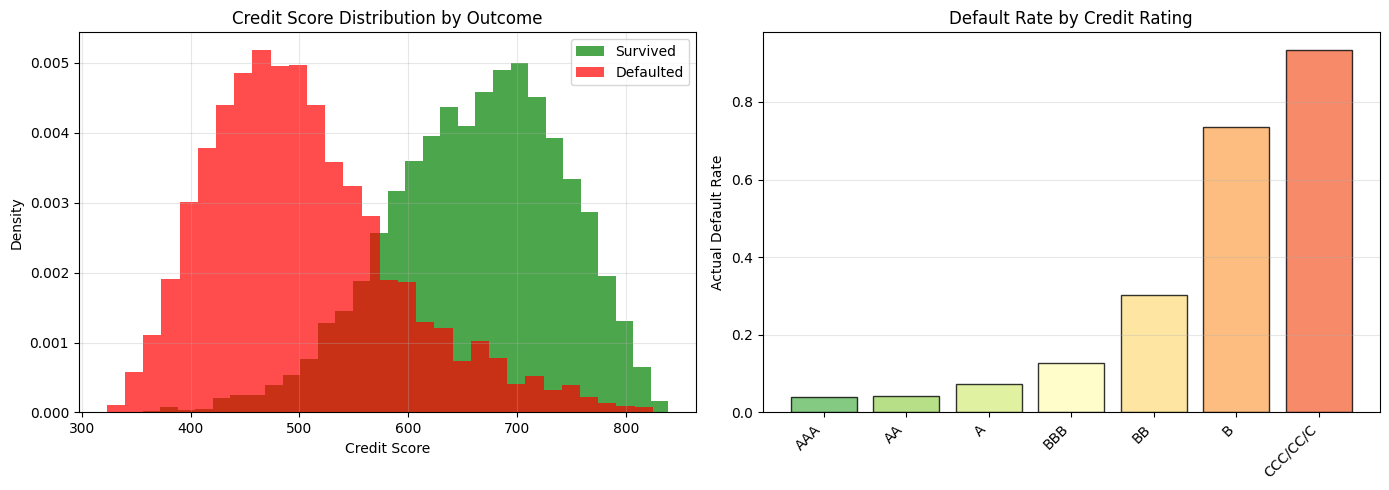

In [12]:
# Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
ax = axes[0]
ax.hist(credit_scores[y_full == 1], bins=30, alpha=0.7, color='green', label='Survived', density=True)
ax.hist(credit_scores[y_full == 0], bins=30, alpha=0.7, color='red', label='Defaulted', density=True)
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Credit Score Distribution by Outcome')
ax.legend()
ax.grid(True, alpha=0.3)

# Default rate by score band
ax = axes[1]
band_names = [b.split(' (')[0] for b in band_order if any(df_scores['rating'] == b)]
default_rates = []
for band in band_order:
    mask = df_scores['rating'] == band
    if mask.sum() > 0:
        default_rates.append(1 - df_scores[mask]['actual_survived'].mean())

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(band_names)))
bars = ax.bar(range(len(band_names)), default_rates, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(band_names)))
ax.set_xticklabels([b.split(' (')[0] for b in band_order[:len(band_names)]], rotation=45, ha='right')
ax.set_ylabel('Actual Default Rate')
ax.set_title('Default Rate by Credit Rating')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../docs/score_bands_credit.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 8: Regulatory Output (PD Bucketing)

Under Basel III/IV framework, banks must report their loan portfolios grouped by
Probability of Default (PD) buckets. This section generates the regulatory output
that banks would submit to financial regulators (e.g., OJK in Indonesia, BIS internationally).

**Key Assumptions:**
- Loss Given Default (LGD) = 45% (standard for unsecured UMKM loans)
- Expected Loss (EL) = PD x LGD x EAD (Exposure at Default)


In [13]:
# Compute PD = 1 - P(survival)
pd_values = 1 - p_survival_full
LGD = 0.45  # Loss Given Default assumption

# Define regulatory PD buckets
def assign_pd_bucket(pd_val):
    if pd_val <= 0.01:
        return '0-1%: Virtually no risk'
    elif pd_val <= 0.03:
        return '1-3%: Low risk'
    elif pd_val <= 0.05:
        return '3-5%: Moderate risk'
    elif pd_val <= 0.10:
        return '5-10%: Elevated risk'
    elif pd_val <= 0.20:
        return '10-20%: High risk'
    elif pd_val <= 0.50:
        return '20-50%: Very high risk'
    else:
        return '50%+: Default imminent'

df_reg = pd.DataFrame({
    'pd': pd_values,
    'actual_default': (y_full == 0).astype(int).values
})
df_reg['pd_bucket'] = df_reg['pd'].apply(assign_pd_bucket)
df_reg['expected_loss'] = df_reg['pd'] * LGD

# Bucket order
bucket_order = [
    '0-1%: Virtually no risk',
    '1-3%: Low risk',
    '3-5%: Moderate risk',
    '5-10%: Elevated risk',
    '10-20%: High risk',
    '20-50%: Very high risk',
    '50%+: Default imminent'
]

# Aggregate
reg_stats = []
for bucket in bucket_order:
    mask = df_reg['pd_bucket'] == bucket
    if mask.sum() > 0:
        subset = df_reg[mask]
        reg_stats.append({
            'PD Bucket': bucket,
            'Count': mask.sum(),
            'Pct of Portfolio': f"{mask.sum()/len(df_reg)*100:.1f}%",
            'Actual Default Rate': f"{subset['actual_default'].mean():.1%}",
            'Avg Predicted PD': f"{subset['pd'].mean():.2%}",
            'Expected Loss (EL)': f"{subset['expected_loss'].mean():.2%}"
        })

reg_df = pd.DataFrame(reg_stats)
print("Regulatory PD Bucketing (Basel III/IV Style)")
print("="*100)
print(f"Assumption: LGD = {LGD:.0%}")
print()
print(reg_df.to_string(index=False))

# Save
reg_df.to_csv('../data/pd_regulatory_buckets.csv', index=False)
print("\nSaved to: data/pd_regulatory_buckets.csv")


Regulatory PD Bucketing (Basel III/IV Style)
Assumption: LGD = 45%

             PD Bucket  Count Pct of Portfolio Actual Default Rate Avg Predicted PD Expected Loss (EL)
        1-3%: Low risk      2             0.0%                0.0%            2.40%              1.08%
   3-5%: Moderate risk     17             0.2%                5.9%            4.22%              1.90%
  5-10%: Elevated risk    170             1.7%                2.9%            7.91%              3.56%
     10-20%: High risk   1054            10.5%                4.3%           15.76%              7.09%
20-50%: Very high risk   5173            51.7%               10.2%           34.59%             15.56%
50%+: Default imminent   3584            35.8%               73.2%           66.05%             29.72%

Saved to: data/pd_regulatory_buckets.csv


### Basel III/IV Context

**Regulatory Capital Requirements:**
- Banks must hold capital proportional to the credit risk in their portfolio
- PD (Probability of Default) is a key input to the Internal Ratings-Based (IRB) approach
- Under IRB, banks estimate PD for each rating grade and compute Risk-Weighted Assets (RWA)
- Higher PD = Higher capital charge = Less profitable lending

**For UMKM Lending in Indonesia:**
- OJK (Financial Services Authority) oversees bank compliance
- KUR (Kredit Usaha Rakyat) government-guaranteed loans reduce capital requirements
- This model helps banks identify which UMKMs qualify for standard vs. KUR lending
- PD buckets help set appropriate interest rates (risk-based pricing)


## Section 9: Feature Importance for Bank Decision

Banks require model interpretability for:
1. **Regulatory compliance** - explain why a loan was declined
2. **Fair lending** - ensure no discriminatory patterns
3. **Risk management** - understand what drives defaults

We use SHAP (SHapley Additive exPlanations) to explain individual and aggregate predictions.


In [14]:
import shap

# Sample 500 data points for SHAP (computational efficiency)
np.random.seed(42)
sample_idx = np.random.choice(len(X_full), size=min(500, len(X_full)), replace=False)
X_sample = X_full.iloc[sample_idx]

# Use TreeExplainer for tree-based models
if best_model_name in ['XGBoost', 'LightGBM', 'Random Forest']:
    explainer = shap.TreeExplainer(results[best_model_name]['model'])
    shap_values = explainer.shap_values(X_sample)

    # For binary classifiers, shap_values might be a list [class0, class1]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # class 1 (survived)
    else:
        shap_vals = shap_values
else:
    # For Logistic Regression, use LinearExplainer
    X_sample_scaled = scaler.transform(X_sample)
    explainer = shap.LinearExplainer(results[best_model_name]['model'],
                                     X_train_scaled)
    shap_vals = explainer.shap_values(X_sample_scaled)

print(f"SHAP values computed for {best_model_name}")
print(f"Shape: {np.array(shap_vals).shape}")


SHAP values computed for LightGBM
Shape: (500, 23)


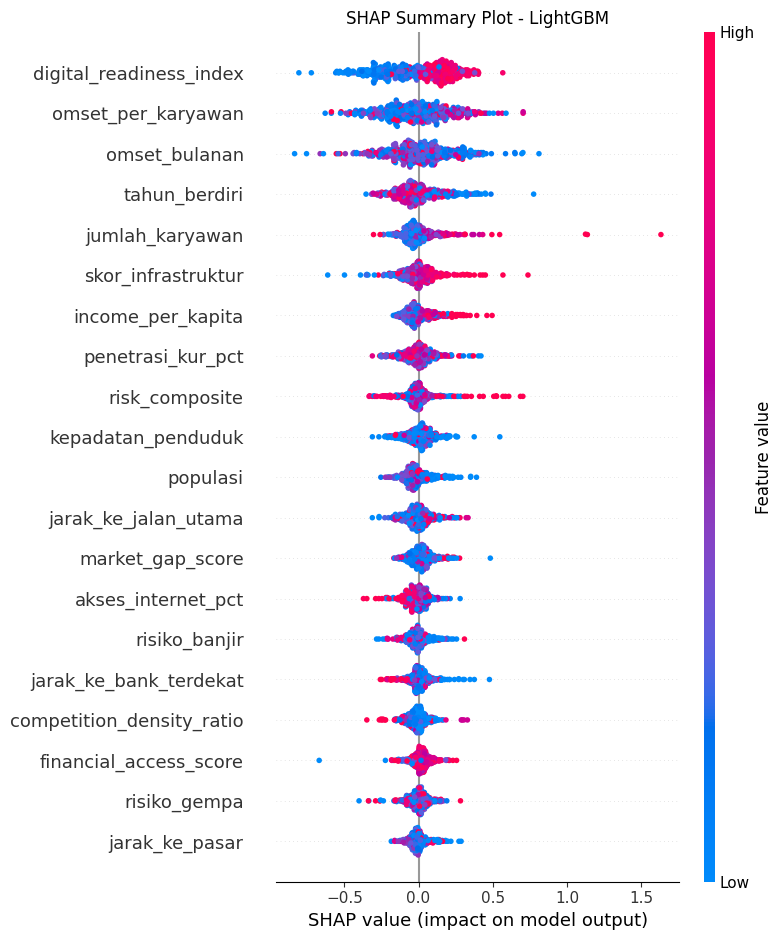

In [15]:
# SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_sample, feature_names=features, show=False)
plt.title(f'SHAP Summary Plot - {best_model_name}')
plt.tight_layout()
plt.savefig('../docs/shap_summary_credit.png', dpi=100, bbox_inches='tight')
plt.show()


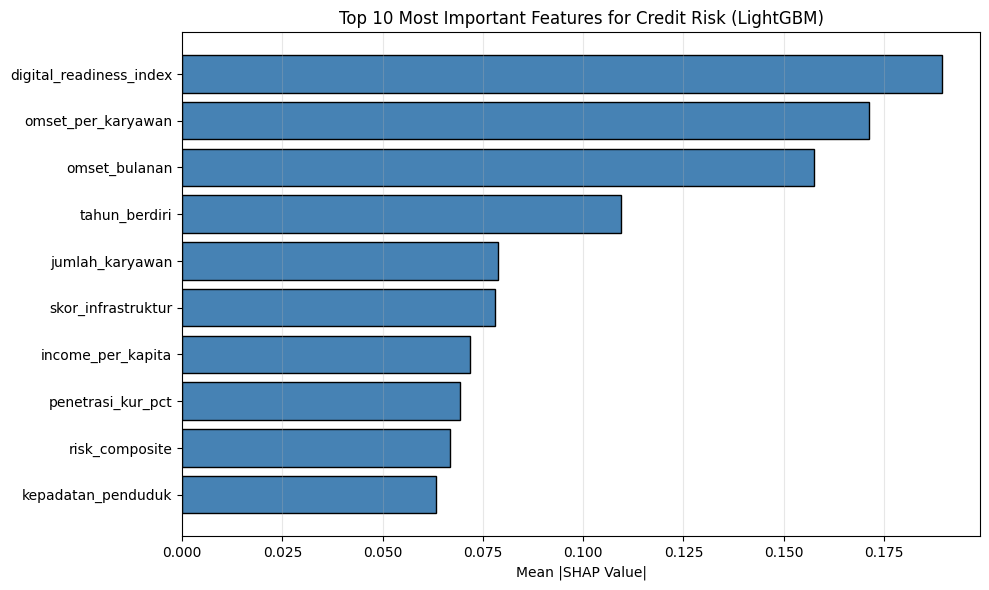

Top 10 features by importance:
  digital_readiness_index: 0.1895
  omset_per_karyawan: 0.1713
  omset_bulanan: 0.1576
  tahun_berdiri: 0.1094
  jumlah_karyawan: 0.0787
  skor_infrastruktur: 0.0780
  income_per_kapita: 0.0718
  penetrasi_kur_pct: 0.0693
  risk_composite: 0.0669
  kepadatan_penduduk: 0.0633


In [16]:
# Top 10 Features Bar Chart
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
feature_importance_shap = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

top10 = feature_importance_shap.head(10)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.barh(range(len(top10)), top10['mean_abs_shap'].values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'Top 10 Most Important Features for Credit Risk ({best_model_name})')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../docs/top10_features_credit.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top 10 features by importance:")
for i, row in top10.iterrows():
    print(f"  {row['feature']}: {row['mean_abs_shap']:.4f}")


Partial Dependence Plots for: ['digital_readiness_index', 'omset_per_karyawan', 'omset_bulanan']


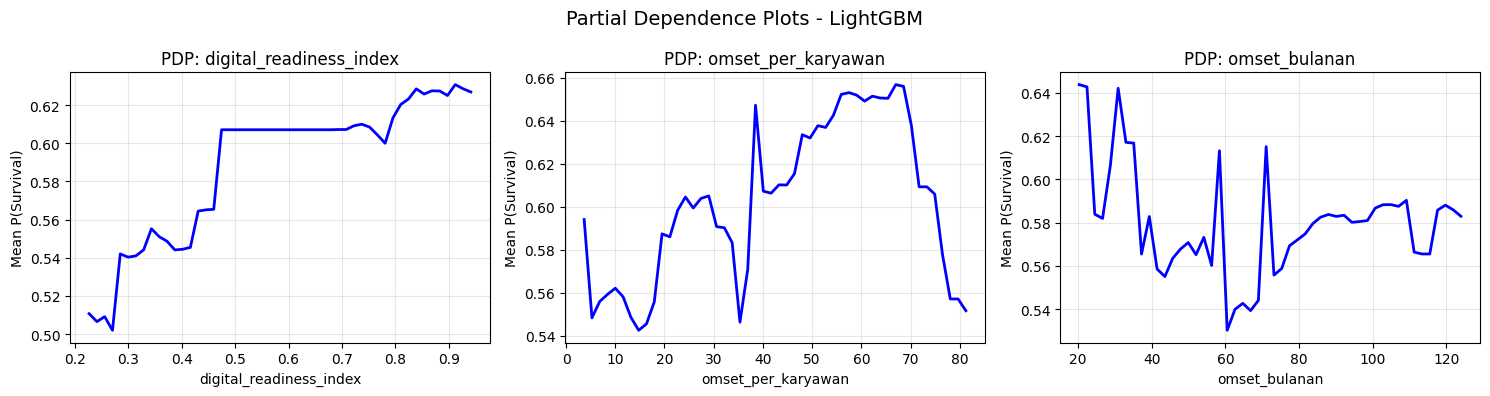

In [17]:
# Partial Dependence Plots for Top 3 Features
# We use a manual PDP computation to avoid sklearn issues with binary features

top3_features = feature_importance_shap.head(3)['feature'].tolist()
print(f"Partial Dependence Plots for: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(top3_features):
    ax = axes[i]
    feat_idx = features.index(feat)

    # Get unique values or create grid
    unique_vals = np.sort(X_train[feat].unique())
    if len(unique_vals) <= 10:
        grid_values = unique_vals
    else:
        grid_values = np.linspace(
            X_train[feat].quantile(0.05),
            X_train[feat].quantile(0.95),
            50
        )

    # Compute PDP manually: average prediction over all samples for each grid value
    pdp_vals = []
    for val in grid_values:
        X_temp = X_train.copy()
        X_temp[feat] = val
        if best_model_name == 'Logistic Regression':
            X_temp_scaled = scaler.transform(X_temp)
            preds = results[best_model_name]['model'].predict_proba(X_temp_scaled)[:, 1]
        else:
            preds = results[best_model_name]['model'].predict_proba(X_temp)[:, 1]
        pdp_vals.append(preds.mean())

    ax.plot(grid_values, pdp_vals, 'b-', linewidth=2, marker='o' if len(grid_values) <= 10 else '')
    ax.set_xlabel(feat)
    ax.set_ylabel('Mean P(Survival)')
    ax.set_title(f'PDP: {feat}')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partial Dependence Plots - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/pdp_credit.png', dpi=100, bbox_inches='tight')
plt.show()


In [18]:
# Decline Reasons Logic
print("Generating Decline Reasons for High-Risk Applications")
print("="*70)
print("For each declined application (PD > 20%), we identify the top 3 negative")
print("SHAP features as reasons for decline.\n")

# Get applications with PD > 20%
declined_mask = pd_values > 0.20
declined_indices = np.where(declined_mask)[0]
print(f"Total applications with PD > 20%: {len(declined_indices)}")
print(f"  ({len(declined_indices)/len(pd_values)*100:.1f}% of portfolio)")

# Find declined applications that are in our SHAP sample
sample_pd = pd_values[sample_idx]
declined_in_sample_mask = sample_pd > 0.20
declined_sample_positions = np.where(declined_in_sample_mask)[0][:5]

print(f"\nExample Decline Reasons (showing up to 5 cases):")
print("-"*70)

for pos in declined_sample_positions[:5]:
    shap_row = shap_vals[pos]
    actual_idx = sample_idx[pos]
    pd_val = pd_values[actual_idx]

    # Find top 3 negative SHAP contributors (pushing toward default)
    feature_shap_pairs = list(zip(features, shap_row, X_sample.iloc[pos].values))
    # Sort by SHAP value (most negative = most pushing toward default)
    feature_shap_pairs.sort(key=lambda x: x[1])
    top3_negative = feature_shap_pairs[:3]

    print(f"\nApplication #{actual_idx} | PD: {pd_val:.1%} | DECLINED")
    reasons = []
    for feat_name, shap_val, feat_val in top3_negative:
        reason = f"  - {feat_name} = {feat_val:.2f} (SHAP: {shap_val:.4f})"
        reasons.append(reason)
        print(reason)

print("\n" + "="*70)
print("These decline reasons can be provided to applicants as required by")
print("fair lending regulations (e.g., Equal Credit Opportunity Act equivalent).")


Generating Decline Reasons for High-Risk Applications
For each declined application (PD > 20%), we identify the top 3 negative
SHAP features as reasons for decline.

Total applications with PD > 20%: 8757
  (87.6% of portfolio)

Example Decline Reasons (showing up to 5 cases):
----------------------------------------------------------------------

Application #6252 | PD: 61.9% | DECLINED
  - tahun_berdiri = 2019.00 (SHAP: -0.1708)
  - omset_bulanan = 69.68 (SHAP: -0.1536)
  - risiko_gempa = 0.73 (SHAP: -0.1268)

Application #4684 | PD: 81.1% | DECLINED
  - digital_readiness_index = 0.25 (SHAP: -0.5396)
  - jarak_ke_bank_terdekat = 19.65 (SHAP: -0.1852)
  - omset_bulanan = 79.40 (SHAP: -0.1603)

Application #1731 | PD: 45.8% | DECLINED
  - omset_bulanan = 64.23 (SHAP: -0.1620)
  - tahun_berdiri = 2018.00 (SHAP: -0.1140)
  - populasi = 209220.00 (SHAP: -0.0634)

Application #4742 | PD: 75.6% | DECLINED
  - risk_composite = 0.41 (SHAP: -0.3336)
  - digital_readiness_index = 0.33 (SHAP: -0

## Section 10: Save Model & Results

We save the best credit risk model and all output tables for downstream use:
- **Model**: Used for scoring new UMKM loan applications
- **Score Bands**: Reference table for credit rating assignment
- **PD Buckets**: Regulatory reporting output


In [19]:
import joblib
import os

# Ensure directories exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# Save best model
model_path = '../models/credit_risk_model.joblib'
joblib.dump(results[best_model_name]['model'], model_path)
print(f"Model saved: {model_path}")
print(f"  Type: {type(results[best_model_name]['model']).__name__}")
print(f"  Best model: {best_model_name}")

# Verify files
print(f"\nOutput files:")
print(f"  models/credit_risk_model.joblib: {os.path.getsize(model_path)/1024:.1f} KB")
print(f"  data/credit_score_bands.csv: saved ({len(score_bands_df)} rows)")
print(f"  data/pd_regulatory_buckets.csv: saved ({len(reg_df)} rows)")

best_row = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]
print(f"\n{'='*60}")
print(f"SUMMARY - Credit Risk Model (Notebook 04)")
print(f"{'='*60}")
print(f"Best Model: {best_model_name}")
print(f"AUC-ROC: {best_row['AUC-ROC']:.4f}")
print(f"KS-Statistic: {best_row['KS-Stat']:.4f}")
print(f"F1-Score: {best_row['F1-Score']:.4f}")
print(f"Score Range: {credit_scores.min():.0f} - {credit_scores.max():.0f}")
print(f"PD Buckets: {len(reg_df)} categories")
print(f"Score Bands: {len(score_bands_df)} rating levels")
print(f"\nNotebook 04 completed successfully!")


Model saved: ../models/credit_risk_model.joblib
  Type: LGBMClassifier
  Best model: LightGBM

Output files:
  models/credit_risk_model.joblib: 666.9 KB
  data/credit_score_bands.csv: saved (7 rows)
  data/pd_regulatory_buckets.csv: saved (6 rows)

SUMMARY - Credit Risk Model (Notebook 04)
Best Model: LightGBM
AUC-ROC: 0.5178
KS-Statistic: 0.0566
F1-Score: 0.6882
Score Range: 323 - 839
PD Buckets: 6 categories
Score Bands: 7 rating levels

Notebook 04 completed successfully!
